Dans ce script, nous allons tester différents modèles de type convolution Nelle pour examiner leur performance. Nous allons ensuite tester s'ils sont robustes lorsqu'on applique une rotation à l'image d'entrée.

In [1]:
import retinoto_py as fovea
dataset = 'bbox'
model_name = 'resnet101'
args = fovea.Params(do_fovea=True, model_name=model_name, num_epochs=40)
args

Params(batch_size=128, num_workers=0, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-5.235987755982989, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='resnet101', num_epochs=40, subset_factor=1, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.85, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)

# learning the `resnet101` on retinotopic images

In [2]:
%ls -lh cached_data/31*

-rw-r--r--@ 1 laurent  staff   7,5K 19 mai   14:05 cached_data/31_fovea_model_name=resnet101_dataset=bbox.json
-rw-r--r--@ 1 laurent  staff   511M 19 mai   14:05 cached_data/31_fovea_model_name=resnet101_dataset=bbox.pth
-rw-r--r--@ 1 laurent  staff   2,1K 27 nov.  18:05 cached_data/31_fovea_model_name=resnet101_dataset=full.json
-rw-r--r--@ 1 laurent  staff   171M 27 nov.  20:42 cached_data/31_fovea_model_name=resnet101_dataset=full.pth


In [3]:
# %rm cached_data/31* # FORCING RECOMPUTE

In [4]:
name = f'31_fovea_model_name={model_name}_dataset={dataset}'
model_filename, json_filename = fovea.do_learning(args, dataset, name)


Load JSON from pre-trained resnet cached_data/31_fovea_model_name=resnet101_dataset=bbox.json
cached_data/31_fovea_model_name=resnet101_dataset=bbox.pth: latest accuracy = 0.757


# Evaluation on the validation dataset

In [5]:
results = fovea.pd.read_json(args.data_cache / f'31_fovea_model_name={model_name}_dataset={dataset}.json')
print(model_name, dataset, '- Accuracy=', results.tail(1)['acc_val'].item())

resnet101 bbox - Accuracy= 0.7566875497000001


In [6]:
model_name, dataset, len(results)

('resnet101', 'bbox', 40)

In [7]:
results.tail(10)

,epoch,i_image,total_image,loss_train,acc_train,acc_val,time
30,30,615168,19070208,0.854314,0.777760,0.753185,342872.089344
31,31,615168,19685376,0.844254,0.779494,0.753521,353769.215172
32,32,615232,615232,0.873770,0.773284,0.753157,1020.202768
33,33,615232,1230464,0.869550,0.774121,0.753418,2006.984951
34,34,615232,1845696,0.863153,0.775797,0.753779,2997.852951
35,35,615232,615232,0.844964,0.780187,0.753443,1016.640006
36,36,615232,1230464,0.839091,0.781521,0.753555,1993.527229
37,37,615232,1845696,0.829887,0.783976,0.754313,2981.353396
38,38,615232,2460928,0.835988,0.782232,0.755357,3977.339782
39,39,615232,3076160,0.829151,0.783256,0.756688,4975.655430


## Plot learning evolution

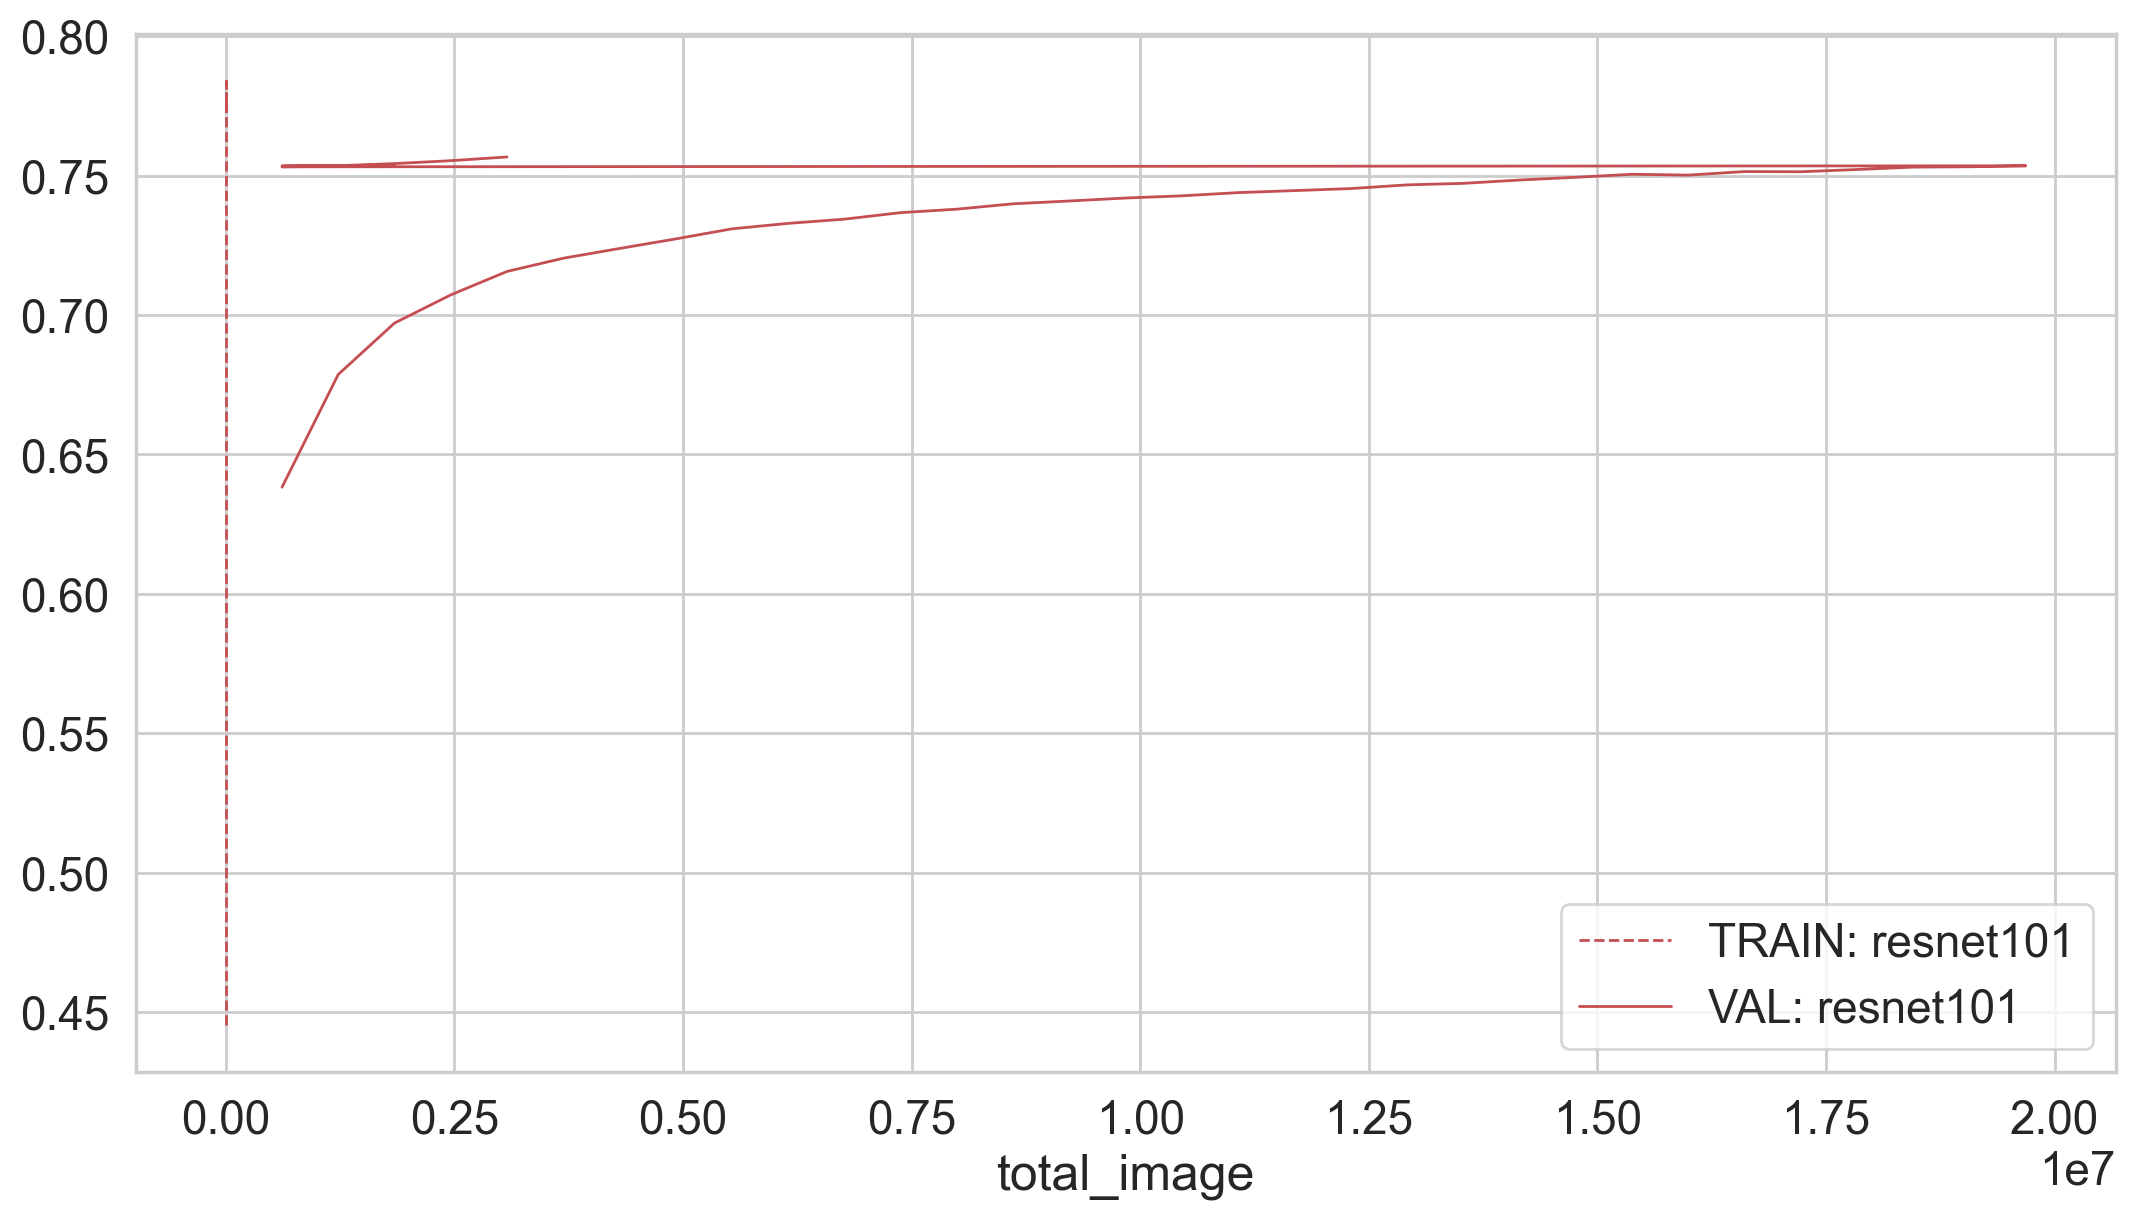

In [8]:
fig, ax = fovea.plt.subplots()
for dataset in ['bbox']:#fovea.params.all_datasets:
    color = 'r'
    lw = 1

    # name = f'31_fovea_model_name={model_name}_dataset={dataset}'
    # cached_data/31_fovea_model_name=resnet101_dataset=bbox.json
    json_filename = args.data_cache / f'31_fovea_model_name={model_name}_dataset={dataset}.json'
    # model_filename, json_filename = fovea.do_learning(args, dataset, name)

    df_train = fovea.pd.read_json(json_filename, orient='records')

    # df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
    ax = df_train.plot(x='epoch', y='acc_train', 
                        c=color, ls='dashed', lw=lw,
                        grid=True, ax=ax, label='TRAIN: ' + args.model_name)    
    ax = df_train.plot(x='total_image', y='acc_val', 
                        c=color, lw=lw,
                        grid=True, ax=ax, label='VAL: ' + args.model_name)   

In [9]:
df_train

,epoch,i_image,total_image,loss_train,acc_train,acc_val,time
0,0,615168,615168,2.802434,0.445400,0.638236,11802.003026
1,1,615168,1230336,1.787017,0.592736,0.678692,25482.743595
2,2,615168,1845504,1.541643,0.636072,0.697116,37577.231044
3,3,615168,2460672,1.416200,0.660124,0.707218,48606.436782
4,4,615168,3075840,1.330604,0.676734,0.715627,59651.745351
5,5,615168,3691008,1.267917,0.688575,0.720367,70520.224556
6,6,615168,4306176,1.220966,0.698595,0.723863,81383.989974
7,7,615168,4921344,1.183720,0.706088,0.727296,92223.103028
8,8,615168,5536512,1.148218,0.713859,0.730917,103051.996062
9,9,615168,6151680,1.117802,0.720174,0.732870,113912.028527
